In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scqubits
from functools import partial
import qutip


# 1. Sweep temp, get T1 of f->e, e->f, e->g, g->e

In [4]:
hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s

def diel_spectral_density(omega, EC,temp_in_mK = 20 ,tangent_ref = 1e-5):
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val = np.where(omega < 0, 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) - 1) , 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) )

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* tangent_ref * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ
    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude, first_order_derivative= 0 ):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0

    first_order_part = 2 * A**2 * first_order_derivative**2
    first_order_part *= np.abs(np.log(omega_ir * t))

    second_order_part = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    second_order_part *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return (first_order_part + second_order_part)  **(-1/2)  # ns


def second_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=50):
    h = 1e-3
    derivative_old = 0.0
    # print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - 2 * f(x0) + f(x0 - h)) / h**2
        # print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol*np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maxietam number of iterations")

def first_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=50):
    h = 1e-3
    derivative_old = 0.0
    # print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - f(x0 - h)) / (2 * h)
        # print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol * np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maxietam number of iterations")

def get_frequency(flux,EJ,EC,EL,i,j):
    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL =EL, cutoff = 110,flux = flux,truncated_dim=20)
    vals = qbt.eigenvals()
    return np.abs(vals[j]-vals[i])

class gfIFQ:
    def __init__(self,
                 EJ,
                 EC,
                 EL,
                 flux=0, truncated_dim=5) -> None:
        self.fluxonium = scqubits.Fluxonium(EJ=EJ,
                                            EC=EC,
                                            EL=EL,
                                            flux=flux, cutoff=110,
                                            truncated_dim=truncated_dim)
        self.truncated_dim = truncated_dim
        self.evals = self.fluxonium.eigenvals(evals_count=truncated_dim)
        self.diag_hamiltonian = qutip.Qobj(2 * np.pi * np.diag(self.evals))
        self.phi_tabel = self.fluxonium.matrixelement_table(
            'phi_operator', evals_count=truncated_dim)
        
    def get_T1_c_ops(self,
                  temp_in_mK,
                  loss_tangent_ref,
                  one_over_f_flux_noise_amplitude) -> None:
        # array element [i,j] means transition rate from j to i
        dielectric_T1_array = np.full(
            (self.truncated_dim, self.truncated_dim), np.inf)
        one_over_f_T1_array = np.full(
            (self.truncated_dim, self.truncated_dim), np.inf)
        EL = self.fluxonium.EL
        EC = self.fluxonium.EC
        # T1
        for i in range(self.truncated_dim):
            for j in range(self.truncated_dim):
                if i == j:
                    continue
                freq = (self.evals[i]-self.evals[j]) * 2 * np.pi
                phi_ele = self.phi_tabel[i, j]
                dielectric_T1_array[j, i] = 1 / (np.abs(phi_ele)**2 * diel_spectral_density(
                    freq, EC, temp_in_mK, loss_tangent_ref))
                one_over_f_T1_array[j, i] = 1 / (np.abs(phi_ele)**2 * one_over_f_spectral_density(
                    freq, EL, one_over_f_flux_noise_amplitude))
        with np.errstate(divide='ignore', invalid='ignore'):
            T1_array = 1/(1/dielectric_T1_array + 1/one_over_f_T1_array)
        c_ops = qutip.Qobj(1/np.sqrt(T1_array))
        return c_ops
    
    def get_Tphi_c_ops(self,
                  one_over_f_flux_noise_amplitude) -> None:
        Tphi_array = np.zeros(shape=(self.truncated_dim,))
        # Tphi
        for ql in range(1,self.truncated_dim):
            Tphi_array[ql] = T_phi(
                second_order_derivative=second_order_derivative(partial(
                    get_frequency,
                    EJ=self.fluxonium.EJ,
                    EC=self.fluxonium.EC,
                    EL=self.fluxonium.EL,
                    i=0,j=ql
                    ),x0=0),
                one_over_f_flux_noise_amplitude=one_over_f_flux_noise_amplitude
            )
        threshold = 1e12
        Tphi_array[np.abs(Tphi_array)>threshold] = threshold

        c_ops = qutip.Qobj(np.diag(1/Tphi_array))
        return c_ops

In [47]:
EJ = 4
EC = EJ / 2.7
EL = EJ / 45

qbt = gfIFQ(EJ=EJ, EC=EC, EL=EL)
tlist = np.linspace(0, int(1e4), 1000)

T1_results_data = {}
for temp_in_mK in [10, 20, 30, 40, 50]:
    loss_tangent_ref = 5e-6
    one_over_f_flux_noise_amplitude = 1e-6

    result = qutip.mesolve(
        rho0=qutip.basis(qbt.truncated_dim, 2),
        H=qbt.diag_hamiltonian,
        tlist=tlist,
        c_ops=qbt.get_T1_c_ops(
            temp_in_mK,
            loss_tangent_ref,
            one_over_f_flux_noise_amplitude
        ),
        e_ops=[qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(5)],
        args=None,
        options=qutip.Options(store_states=True, nsteps=1200000, num_cpus=1),
        progress_bar=qutip.ui.progressbar.EnhancedTextProgressBar(),
    )

    Tphi_c_ops = qbt.get_Tphi_c_ops(
        one_over_f_flux_noise_amplitude=one_over_f_flux_noise_amplitude
    )

    gamma_phi = np.abs(Tphi_c_ops.full().diagonal()[2])

    # Store results and other parameters for this run
    T1_results_data[temp_in_mK] = {
        "result": result,
        "gamma_phi": gamma_phi,
    }

Tphi_results_data = {}
temp_in_mK = 20
loss_tangent_ref = 5e-6

result = qutip.mesolve(
    rho0=qutip.basis(qbt.truncated_dim, 2),
    H=qbt.diag_hamiltonian,
    tlist=tlist,
    c_ops=qbt.get_T1_c_ops(
        temp_in_mK,
        loss_tangent_ref,
        one_over_f_flux_noise_amplitude
    ),
    e_ops=[qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(5)],
    args=None,
    options=qutip.Options(store_states=True, nsteps=1200000, num_cpus=1),
    progress_bar=qutip.ui.progressbar.EnhancedTextProgressBar(),
)
for one_over_f_flux_noise_amplitude in [1e-6, 2.5e-6, 5e-6, 7.5e-6, 1e-5]:
    Tphi_c_ops = qbt.get_Tphi_c_ops(
        one_over_f_flux_noise_amplitude=one_over_f_flux_noise_amplitude
    )
    gamma_phi = np.abs(Tphi_c_ops.full().diagonal()[2])
    # Store results and other parameters for this run
    Tphi_results_data[one_over_f_flux_noise_amplitude] = {
        "gamma_phi": gamma_phi,
    }

 Total run time:   2.25s*] Elapsed 2.25s / Remaining 00:00:00:00
 [          2%           ] Elapsed 0.18s / Remaining 00:00:00:09

 /tmp/ipykernel_6238/1018297768.py: 135

 Total run time:   9.50s*] Elapsed 9.50s / Remaining 00:00:00:00
 Total run time:   4.90s*] Elapsed 4.90s / Remaining 00:00:00:00
 Total run time:   5.66s*] Elapsed 5.66s / Remaining 00:00:00:00
 Total run time:   6.00s*] Elapsed 5.99s / Remaining 00:00:00:00
 Total run time:   9.41s*] Elapsed 9.41s / Remaining 00:00:00:00


 /tmp/ipykernel_6238/3824693605.py: 16RuntimeWarning: invalid value encountered in divide
 /tmp/ipykernel_6238/3824693605.py: 24

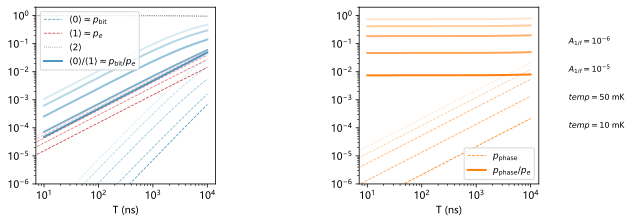

In [67]:
fig = plt.figure(figsize=(10, 3)) 
gs0 = fig.add_gridspec(nrows=1, ncols=1,left=0.15, right=0.4,bottom=0.15,top = 0.97)
gs1 = fig.add_gridspec(nrows=1, ncols=1,left=0.6, right=0.85,bottom=0.15,top = 0.97)
axes = [fig.add_subplot(gs0[0]), fig.add_subplot(gs1[0])]

for (temp_in_mK, data), alpha in zip(T1_results_data.items(),[1, 0.7, 0.6, 0.4, 0.2]):
    result = data["result"]
    gamma_phi = data["gamma_phi"]
    
    axes[0].plot(tlist, result.expect[0], label=rf"$\langle{{0}}\rangle$",
            linestyle='--', lw=0.8, color='#4999c3', alpha=alpha)
    axes[0].plot(tlist, result.expect[1], label=rf"$\langle{{1}}\rangle = p_e$",
            linestyle='--', lw=0.8, color='#d5373d', alpha=alpha)
    axes[0].plot(tlist, result.expect[2], label=rf"$\langle{{2}}\rangle$",
            linestyle=':', lw=0.8, color='grey', alpha=0.5)
    axes[0].plot(tlist, result.expect[0] / result.expect[1], label=rf"$\langle{{0}}\rangle/\langle{{1}}\rangle = p_X/p_e$",
            linestyle='-', lw=2, color='#4999c3', alpha=alpha)

for (one_over_f_flux_noise_amplitude, data), alpha in zip(Tphi_results_data.items(),[1, 0.7, 0.6, 0.4, 0.2]):
    result = T1_results_data[20]["result"]
    gamma_phi = data["gamma_phi"]
    axes[1].plot(tlist, 1 - np.exp(-gamma_phi * tlist), label=rf"$p_\phi$",
            linestyle='--', lw=0.8, color='#ff7f0e', alpha=alpha)
    axes[1].plot(tlist, (1 - np.exp(-gamma_phi * tlist)) / result.expect[1], label=rf"$ p_\phi/p_e$",
            linestyle='-', lw=2, color='#ff7f0e', alpha=alpha)

for ax in axes:
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_ylim(1e-6, 2)
        ax.set_xlabel(r'T (ns)')

axes[0].legend(handles=[
    plt.Line2D([0], [0], linestyle='--', lw=0.8, color='#4999c3', label=rf"$\langle{{0}}\rangle \approx p_\text{{bit}}$"),
    plt.Line2D([0], [0], linestyle='--', lw=0.8, color='#d5373d', label=rf"$\langle{{1}}\rangle \approx p_e$"),
    plt.Line2D([0], [0], linestyle=':', lw=0.8, color='grey', label=rf"$\langle{{2}}\rangle$"),
    plt.Line2D([0], [0], linestyle='-', lw=2, color='#4999c3',label=rf"$\langle{{0}}\rangle/\langle{{1}}\rangle \approx p_\text{{bit}}/p_e$"),

], loc='upper left',prop={'size': 9})

axes[1].legend(handles=[
    plt.Line2D([0], [0], linestyle='--', lw=0.8, color='#ff7f0e', label=rf"$p_\text{{phase}}$"),
    plt.Line2D([0], [0], linestyle='-', lw=2, color='#ff7f0e', label=rf"$ p_\text{{phase}}/p_e$")
], loc='lower right',prop={'size': 9})

axes[1].text(5e4,1e-4,rf'$temp=10$ mK',size = 8)
axes[1].text(5e4,1e-3,rf'$temp=50$ mK',size = 8)
axes[1].text(5e4,1e-2,rf'$A_{{1/f}}=10^{{-5}}$',size = 8)
axes[1].text(5e4,1e-1,rf'$A_{{1/f}}=10^{{-6}}$',size = 8)
fig.savefig('gf_mesolve.pdf')